# Numerical convergence of the Møller-scattering integrals

This notebook is a numerical verification protocol for the normalization, differential probability, and total probability. It deliberately separates **quadrature convergence** (number of nodes) from **domain convergence or physical cutoff dependence** (integration limits). Natural units $\hbar=c=1$ are used.

## Verification principle

For every integral we perform two different tests:

1. Keep the integration domain fixed and increase the number of quadrature nodes. A stable plateau measures the discretization error.
2. Keep a sufficiently dense quadrature fixed and enlarge the finite integration domain. A stable plateau measures the truncation error.

No numerical result is declared to be an exact reference. For node scans we monitor the local relative refinement $\delta_i=|Q_i-Q_{i-1}|/|Q_i|$. For domain scans we monitor the relative contribution of each newly added momentum shell. An optimal setting is the first one after which all measured refinements stay below the chosen tolerance. The lower limit of the $k_{3\perp}$ integral is special: because of the forward-scattering singularity it is generally a **physical acceptance cutoff**, so changing it changes the observable rather than merely improving the numerical approximation.

In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

import moller_vortex as mv

MEV_TO_EV = 1.0e6
PLOT_FLOOR = 1.0e-16
SATURATION_TOLERANCE = 1.0e-4  # change this to match the accuracy required by the plot

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11.0,
    "axes.titlesize": 15.0,
    "axes.labelsize": 13.0,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 10.0,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


c:\Users\User\Documents\moller_vortex\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def relative_step_change(values):
    values = np.asarray(values, dtype=float)
    changes = np.full_like(values, np.nan, dtype=float)
    denominator = np.maximum(np.abs(values[1:]), np.finfo(float).tiny)
    changes[1:] = np.abs(values[1:] - values[:-1]) / denominator
    return changes


def relative_shell_contribution(shell_values, cumulative_values):
    shell_values = np.asarray(shell_values, dtype=float)
    cumulative_values = np.asarray(cumulative_values, dtype=float)
    denominator = np.maximum(np.abs(cumulative_values), np.finfo(float).tiny)
    return np.abs(shell_values) / denominator


def last_step_change(values):
    return np.nanmax(relative_step_change(values)[-1])


def timed_scan(description, parameter_values, evaluate):
    started = time.perf_counter()
    results = [
        evaluate(value)
        for value in tqdm(parameter_values, desc=description, unit="case", dynamic_ncols=True)
    ]
    elapsed = time.perf_counter() - started
    print(f"{description}: {elapsed:.2f} s")
    return np.asarray(results)


def plot_diagnostics(ax, x, diagnostics, labels, xlabel, ylabel):
    diagnostics = np.asarray(diagnostics, dtype=float)
    if diagnostics.ndim == 1:
        diagnostics = diagnostics[:, None]
    for column, label in enumerate(labels):
        ax.semilogy(
            x, np.maximum(diagnostics[:, column], PLOT_FLOOR), "o-", label=label
        )
    ax.axhline(
        SATURATION_TOLERANCE, color="black", linestyle="--", linewidth=1.0,
        label=rf"tolerance $={SATURATION_TOLERANCE:g}$",
    )
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.legend()


def saturation_parameter(parameters, diagnostics, tolerance=SATURATION_TOLERANCE):
    diagnostics = np.asarray(diagnostics, dtype=float)
    if diagnostics.ndim > 1:
        diagnostics = np.max(diagnostics, axis=tuple(range(1, diagnostics.ndim)))
    for index in range(len(parameters)):
        if np.all(diagnostics[index:] < tolerance):
            return parameters[index]
    return None

## Physical parameters

Keep this cell synchronized with the calculation whose plots are being verified. Spatial packet widths and the impact parameter are entered in nm; energy widths and momenta are stored in MeV.

In [3]:
packet_parameters = (
    {
        "name": "Packet 1",
        "ell": 5,
        "sigma_perp": mv.spatial_width_nm_to_momentum_mev(10.0),
        "sigma_parallel": mv.spatial_width_nm_to_momentum_mev(5.0),
        "sigma_energy": mv.spatial_width_nm_to_momentum_mev(5.0),
        "k0_z": +10.0,
    },
    {
        "name": "Packet 2",
        "ell": 0,
        "sigma_perp": mv.spatial_width_nm_to_momentum_mev(2.0),
        "sigma_parallel": mv.spatial_width_nm_to_momentum_mev(1.0),
        "sigma_energy": mv.spatial_width_nm_to_momentum_mev(1.0),
        "k0_z": -10.0,
    },
)

impact_nm = np.array((5.0, 0.0))
impact = impact_nm / mv.HBARC_MEV_NM
packet_labels = tuple(parameters["name"] for parameters in packet_parameters)
for parameters in packet_parameters:
    print(
        f"{parameters['name']}: ell = {parameters['ell']:+d}, "
        f"sigma_perp = {mv.HBARC_MEV_NM / parameters['sigma_perp']:.8g} nm, "
        f"sigma_parallel = {mv.HBARC_MEV_NM / parameters['sigma_parallel']:.8g} nm, "
        f"sigma_energy = {parameters['sigma_energy']:.8e} MeV, "
        f"k0_z = {parameters['k0_z']:+.8e} MeV"
    )
print(f"Impact parameter = ({impact_nm[0]:.8g}, {impact_nm[1]:.8g}) nm")

parameter_text = (
    rf"$\ell_1={packet_parameters[0]['ell']:+d},\quad "
    rf"\ell_2={packet_parameters[1]['ell']:+d};\qquad "
    rf"\mathbf{{b}}=({impact_nm[0]:.4g},\,{impact_nm[1]:.4g})\,\mathrm{{nm}}$"
)


Packet 1: ell = +5, sigma_perp = 10 nm, sigma_parallel = 5 nm, sigma_energy = 3.94653961e-05 MeV, k0_z = +1.00000000e+01 MeV
Packet 2: ell = +0, sigma_perp = 2 nm, sigma_parallel = 1 nm, sigma_energy = 1.97326980e-04 MeV, k0_z = -1.00000000e+01 MeV
Impact parameter = (5, 0) nm


## 1. Normalization integral

The numerical integral is

$$I_N=\int_0^\infty k_\perp\,dk_\perp\int_{-\infty}^{+\infty}dk_z\,\frac{|\phi(\mathbf k)|^2}{4\pi^2\,2E_{\mathbf k}}=1.$$

The azimuthal integral has already been taken analytically. The radial scale of $|\phi|^2$ is $\sigma_\perp/\sqrt2$. In the leading longitudinal expansion the scale of $|\phi|^2$ is

$$\sigma_{k_z,N}=\left(\frac{2v^2}{\sigma_E^2}+\frac{2}{\sigma_\parallel^2}\right)^{-1/2}.$$

The normalization constant $\mathcal{N}$ is monitored directly. Each point uses its own quadrature; the plotted quantity is the relative change of $\mathcal{N}$ caused by the latest refinement. No point is treated as exact.

In [4]:
def make_packet(parameters, *, n_kperp, n_kz, kperp_widths, kz_widths):
    central_energy = np.sqrt(mv.ELECTRON_MASS**2 + parameters["k0_z"]**2)
    velocity = parameters["k0_z"] / central_energy
    k_perp_scale = parameters["sigma_perp"] / np.sqrt(2.0)
    k_z_scale = (
        2.0 * velocity**2 / parameters["sigma_energy"]**2
        + 2.0 / parameters["sigma_parallel"]**2
    ) ** (-0.5)
    normalization_grid = mv.NormalizationGrid(
        k_perp=mv.Axis(0.0, kperp_widths * k_perp_scale, int(n_kperp), "gauss"),
        k_z=mv.Axis(
            parameters["k0_z"] - kz_widths * k_z_scale,
            parameters["k0_z"] + kz_widths * k_z_scale,
            int(n_kz),
            "gauss",
        ),
    )
    return mv.VortexPacket(
        ell=parameters["ell"],
        sigma_perp=parameters["sigma_perp"],
        sigma_parallel=parameters["sigma_parallel"],
        sigma_energy=parameters["sigma_energy"],
        k0_z=parameters["k0_z"],
        normalization_grid=normalization_grid,
    )


In [5]:
NORMALIZATION_FIXED = {
    "n_kperp": 160,
    "n_kz": 160,
    "kperp_widths": 15.0,
    "kz_widths": 15.0,
}

analysis_packets = tuple(
    make_packet(parameters, **NORMALIZATION_FIXED)
    for parameters in packet_parameters
)

for label, packet in zip(packet_labels, analysis_packets):
    print(f"{label}: N = {packet.norm:.12e} MeV^-1")

Packet 1: N = 2.864355070953e+08 MeV^-1
Packet 2: N = 2.561957060018e+07 MeV^-1


In [6]:
def scan_normalization(parameter_name, values):
    def evaluate(value):
        settings = dict(NORMALIZATION_FIXED)
        settings[parameter_name] = value
        candidate_packets = tuple(
            make_packet(parameters, **settings) for parameters in packet_parameters
        )
        return [packet.norm for packet in candidate_packets]

    return timed_scan(f"Normalization: {parameter_name}", values, evaluate)

### Convergence with the number of nodes

Only one axis is refined at a time; the other axis and both domain widths remain fixed at their largest analysis settings. The first point has no $\delta_i$ because there is no preceding refinement.

Normalization: n_kperp: 100%|██████████| 12/12 [00:00<00:00, 186.53case/s]


Normalization: n_kperp: 0.07 s


Normalization: n_kz: 100%|██████████| 12/12 [00:00<00:00, 176.11case/s]


Normalization: n_kz: 0.07 s


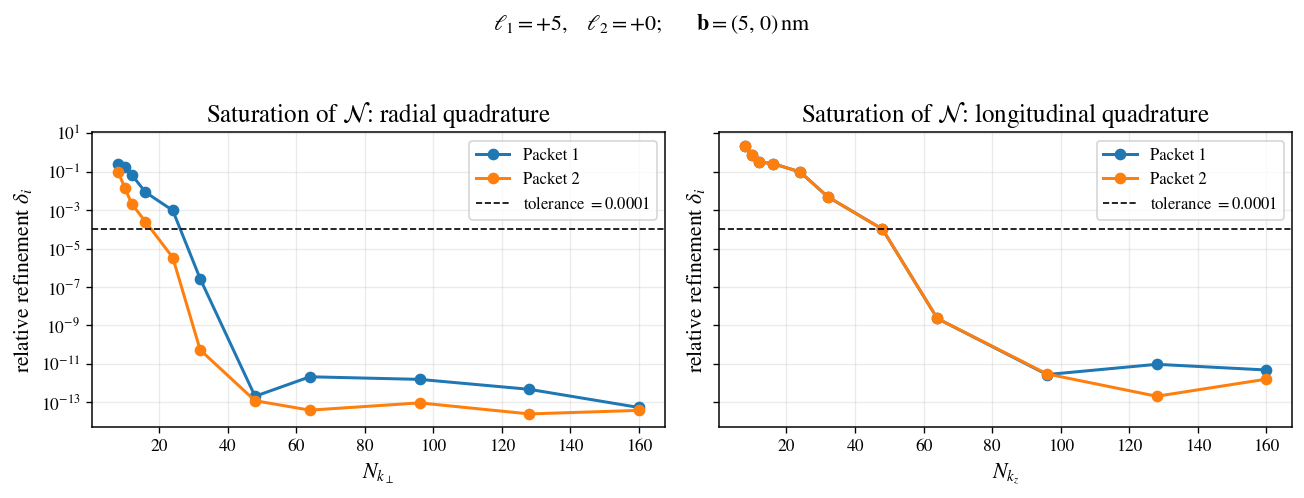

In [7]:
normalization_node_counts = np.array((6, 8, 10, 12, 16, 24, 32, 48, 64, 96, 128, 160))
normalization_kperp_node_values = scan_normalization("n_kperp", normalization_node_counts)
normalization_kz_node_values = scan_normalization("n_kz", normalization_node_counts)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
plot_diagnostics(
    axes[0], normalization_node_counts[1:],
    relative_step_change(normalization_kperp_node_values)[1:],
    packet_labels, r"$N_{k_\perp}$", r"relative refinement $\delta_i$",
)
plot_diagnostics(
    axes[1], normalization_node_counts[1:],
    relative_step_change(normalization_kz_node_values)[1:],
    packet_labels, r"$N_{k_z}$", r"relative refinement $\delta_i$",
)
axes[0].set_title(r"Saturation of $\mathcal{N}$: radial quadrature")
axes[1].set_title(r"Saturation of $\mathcal{N}$: longitudinal quadrature")
fig.suptitle(parameter_text)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
plt.show()

### Convergence with the finite domain

The horizontal coordinate is the number of effective $|\phi|^2$ widths included in the finite domain. The node count is kept fixed at its largest analysis value. Saturation means that adding the next part of the Gaussian tail changes $\mathcal{N}$ by less than the selected tolerance.

Normalization: kperp_widths: 100%|██████████| 11/11 [00:00<00:00, 114.82case/s]


Normalization: kperp_widths: 0.10 s


Normalization: kz_widths: 100%|██████████| 11/11 [00:00<00:00, 121.56case/s]


Normalization: kz_widths: 0.09 s


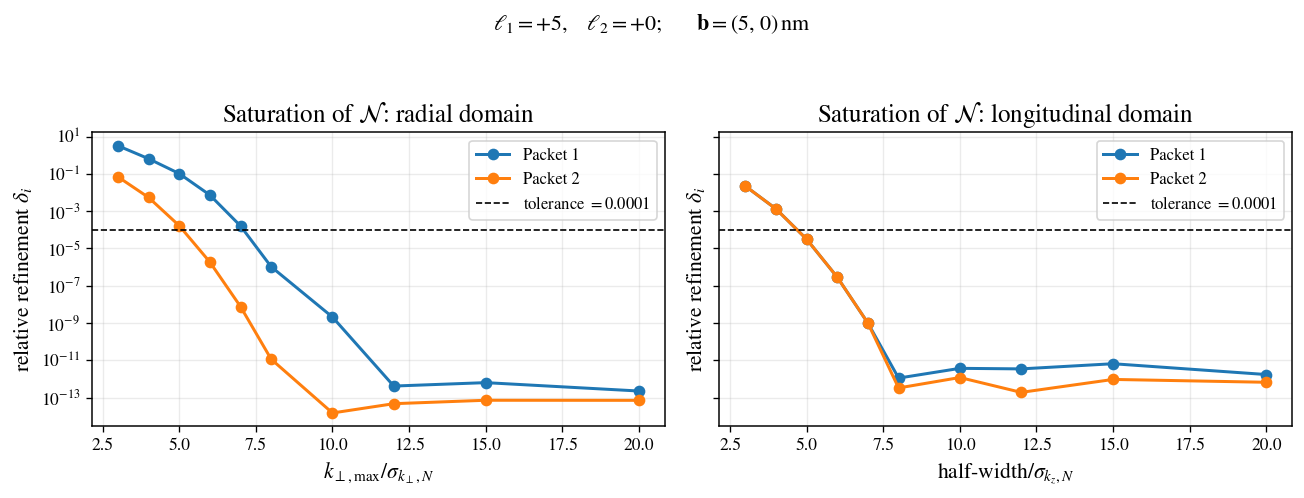

In [8]:
normalization_domain_widths = np.array((2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 15.0, 20.0 ))
normalization_kperp_domain_values = scan_normalization("kperp_widths", normalization_domain_widths)
normalization_kz_domain_values = scan_normalization("kz_widths", normalization_domain_widths)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
plot_diagnostics(
    axes[0], normalization_domain_widths[1:],
    relative_step_change(normalization_kperp_domain_values)[1:], packet_labels,
    r"$k_{\perp,\max}/\sigma_{k_\perp,N}$", r"relative refinement $\delta_i$",
)
plot_diagnostics(
    axes[1], normalization_domain_widths[1:],
    relative_step_change(normalization_kz_domain_values)[1:], packet_labels,
    r"half-width$/\sigma_{k_z,N}$", r"relative refinement $\delta_i$",
)
axes[0].set_title(r"Saturation of $\mathcal{N}$: radial domain")
axes[1].set_title(r"Saturation of $\mathcal{N}$: longitudinal domain")
fig.suptitle(parameter_text)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
plt.show()

## 2. Differential probability

After the analytic longitudinal integration, the remaining numerical integral is

$$\frac{dP}{d^2K_\perp}=C\int_{k_{3\perp,\min}}^{k_{3\perp,\max}}k_{3\perp}\,dk_{3\perp}\int_0^{2\pi}d\varphi_3\,|T_\perp|^2.$$

The normalization grids are now fixed at their largest analysis settings, so the following plots isolate the $k_{3\perp}$ and $\varphi_3$ quadratures. Several $K_\perp$ probes are tested because saturation at one point does not guarantee saturation over a two-dimensional map. The map pixel count is not an integration parameter. Here $\sigma_T=\sqrt{\sigma_{1\perp}^2+\sigma_{2\perp}^2}$ is only a convenient momentum scale for selecting and labeling $K_\perp$ points; it is not an additional packet width.

In [9]:
packet1, packet2 = analysis_packets
sigma_total_perp = np.hypot(packet1.sigma_perp, packet2.sigma_perp)

probe_coefficients = np.array(((0.0, 0.0), (0.5, -0.25), (2.0, 1.0)))
total_k_probes = sigma_total_perp * probe_coefficients
probe_labels = tuple(
    rf"$K_\perp/\sigma_T=({x:g},{y:g})$" for x, y in probe_coefficients
)
k3_perp_range = (0.010, 0.050)  # MeV: the physical window used in the main calculation

for label, point in zip(probe_labels, total_k_probes):
    print(f"{label}: K_perp = ({point[0] * MEV_TO_EV:+.8e}, {point[1] * MEV_TO_EV:+.8e}) eV")

$K_\perp/\sigma_T=(0,0)$: K_perp = (+0.00000000e+00, +0.00000000e+00) eV
$K_\perp/\sigma_T=(0.5,-0.25)$: K_perp = (+5.03087062e+01, -2.51543531e+01) eV
$K_\perp/\sigma_T=(2,1)$: K_perp = (+2.01234825e+02, +1.00617412e+02) eV


In [10]:
def evaluate_differential_probes(n_radial, n_phi, k3_min=k3_perp_range[0], k3_max=k3_perp_range[1]):
    grid = mv.ProbabilityGrid(
        k3_perp=mv.Axis(k3_min, k3_max, int(n_radial), "gauss"),
        k3_phi=mv.Axis(0.0, 2.0 * np.pi, int(n_phi), "periodic"),
    )
    return np.array([
        mv.differential_probability(point, packet1, packet2, grid, impact=impact)
        for point in total_k_probes
    ])

### Convergence with the number of nodes

The physical interval is fixed at $k_{3\perp}\in[0.010,0.050]$ MeV. The radial Gauss–Legendre and periodic angular quadratures are refined separately.

Differential probability: radial nodes: 100%|██████████| 9/9 [00:00<00:00, 411.36case/s]


Differential probability: radial nodes: 0.02 s


Differential probability: angular nodes: 100%|██████████| 10/10 [00:00<00:00, 181.58case/s]


Differential probability: angular nodes: 0.06 s


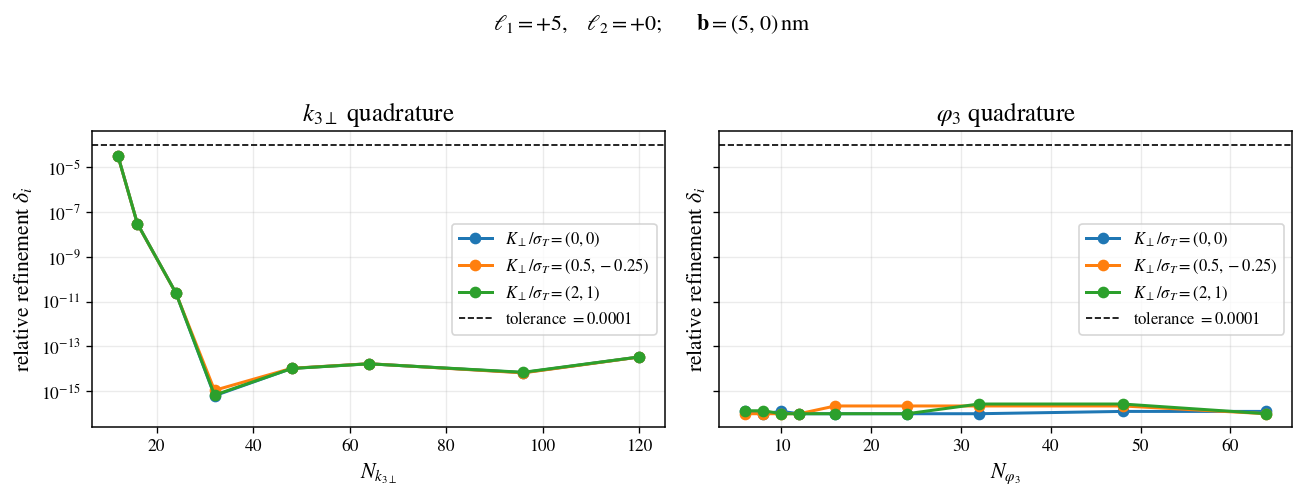

Differential probabilities at the largest tested radial grid:
  $K_\perp/\sigma_T=(0,0)$: 1.044144662876e-07 MeV^-2
  $K_\perp/\sigma_T=(0.5,-0.25)$: 2.387022808027e-07 MeV^-2
  $K_\perp/\sigma_T=(2,1)$: 7.622561234141e-10 MeV^-2


In [11]:
DIFFERENTIAL_FIXED_N_RADIAL = 120
DIFFERENTIAL_FIXED_N_PHI = 64
differential_radial_counts = np.array((8, 12, 16, 24, 32, 48, 64, 96, 120))
differential_phi_counts = np.array((4, 6, 8, 10, 12, 16, 24, 32, 48, 64))
differential_radial_values = timed_scan(
    "Differential probability: radial nodes",
    differential_radial_counts,
    lambda count: evaluate_differential_probes(count, DIFFERENTIAL_FIXED_N_PHI),
)
differential_phi_values = timed_scan(
    "Differential probability: angular nodes",
    differential_phi_counts,
    lambda count: evaluate_differential_probes(DIFFERENTIAL_FIXED_N_RADIAL, count),
)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
plot_diagnostics(
    axes[0], differential_radial_counts[1:],
    relative_step_change(differential_radial_values)[1:],
    probe_labels, r"$N_{k_{3\perp}}$", r"relative refinement $\delta_i$",
)
plot_diagnostics(
    axes[1], differential_phi_counts[1:],
    relative_step_change(differential_phi_values)[1:],
    probe_labels, r"$N_{\varphi_3}$", r"relative refinement $\delta_i$",
)
axes[0].set_title(r"$k_{3\perp}$ quadrature")
axes[1].set_title(r"$\varphi_3$ quadrature")
fig.suptitle(parameter_text)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
plt.show()

print("Differential probabilities at the largest tested radial grid:")
for label, value in zip(probe_labels, differential_radial_values[-1]):
    print(f"  {label}: {value:.12e} MeV^-2")

### Dependence on the radial interval

The upper-limit scan can reveal saturation of the radial tail. To avoid changing the node density when the domain grows, the integral is accumulated from separately resolved momentum shells. The lower-limit scan uses the same shell decomposition and is plotted as the observable itself, not as a numerical error: approaching the forward singularity can prevent a plateau and must be interpreted as detector/cutoff dependence. The angular domain is exactly one full period $[0,2\pi)$ and therefore is not truncated.

Differential probability: upper shells: 100%|██████████| 11/11 [00:00<00:00, 189.37case/s]


Differential probability: upper shells: 0.06 s


Differential probability: lower-cutoff shells: 100%|██████████| 9/9 [00:00<00:00, 185.65case/s]


Differential probability: lower-cutoff shells: 0.05 s


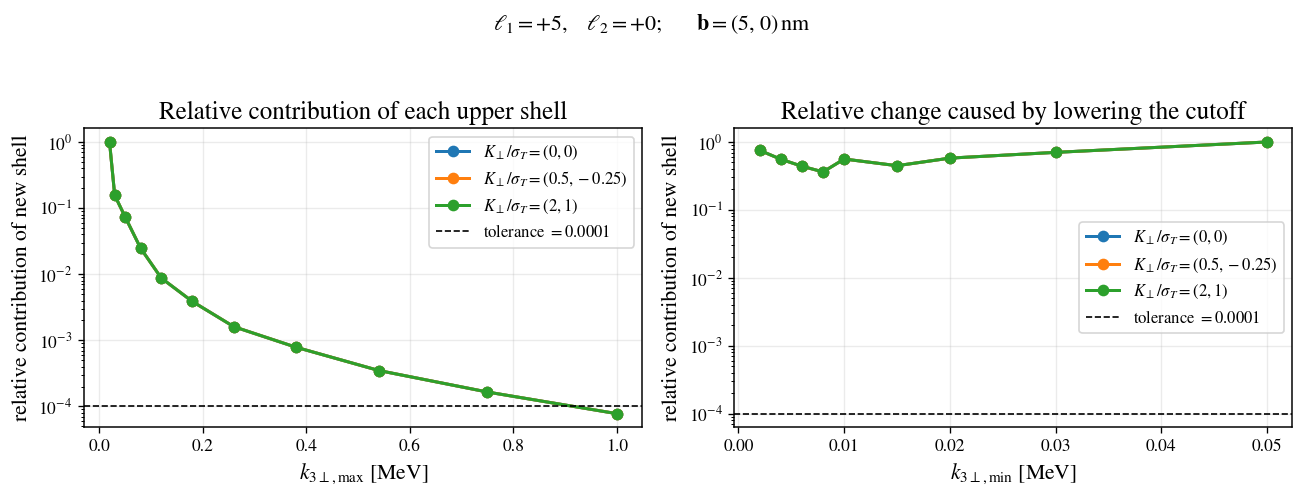

In [12]:
differential_upper_edges = np.array((0.010, 0.020, 0.030, 0.050, 0.080, 0.120, 0.180, 0.260, 0.380, 0.540, 0.750, 1.000))
differential_upper_shells = tuple(zip(differential_upper_edges[:-1], differential_upper_edges[1:]))
differential_upper_shell_values = timed_scan(
    "Differential probability: upper shells",
    differential_upper_shells,
    lambda shell: evaluate_differential_probes(
        DIFFERENTIAL_FIXED_N_RADIAL, DIFFERENTIAL_FIXED_N_PHI, shell[0], shell[1]
    ),
)
differential_upper_limits = differential_upper_edges[1:]
differential_upper_values = np.cumsum(differential_upper_shell_values, axis=0)
differential_upper_fractions = relative_shell_contribution(
    differential_upper_shell_values, differential_upper_values
)

differential_lower_edges = np.array((0.002, 0.004, 0.006, 0.008, 0.010, 0.015, 0.020, 0.030, 0.050, 0.100))
differential_lower_shells = tuple(zip(differential_lower_edges[:-1], differential_lower_edges[1:]))
differential_lower_shell_values = timed_scan(
    "Differential probability: lower-cutoff shells",
    differential_lower_shells,
    lambda shell: evaluate_differential_probes(
        DIFFERENTIAL_FIXED_N_RADIAL, DIFFERENTIAL_FIXED_N_PHI, shell[0], shell[1]
    ),
)
differential_lower_limits = differential_lower_edges[:-1]
differential_lower_values = np.cumsum(differential_lower_shell_values[::-1], axis=0)[::-1]
differential_lower_fractions = relative_shell_contribution(
    differential_lower_shell_values, differential_lower_values
)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
plot_diagnostics(
    axes[0], differential_upper_limits, differential_upper_fractions,
    probe_labels, r"$k_{3\perp,\max}$ [MeV]",
    "relative contribution of new shell",
)
plot_diagnostics(
    axes[1], differential_lower_limits, differential_lower_fractions,
    probe_labels, r"$k_{3\perp,\min}$ [MeV]",
    "relative contribution of new shell",
)
axes[0].set_title("Relative contribution of each upper shell")
axes[1].set_title("Relative change caused by lowering the cutoff")
fig.suptitle(parameter_text)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
plt.show()

## 3. Total probability

The total probability adds the outer integral

$$P=\int_0^{K_{\perp,\max}}K_\perp\,dK_\perp\int_0^{2\pi}d\Phi_K\,\frac{dP}{d^2K_\perp}.$$

The inner $k_{3\perp}$ and $\varphi_3$ quadratures were verified in the differential-probability section and are held fixed here at the production settings. Only the convergence of the outer $K_\perp$ and $\Phi_K$ integrations is tested below.


In [13]:
TOTAL_INNER_N_RADIAL = 32
TOTAL_INNER_N_PHI = 12
TOTAL_FIXED = {
    "n_outer_radial": 80,
    "n_outer_phi": 48,
    "outer_widths": 12.0,
}
def evaluate_total_probability(**changes):
    settings = dict(TOTAL_FIXED)
    settings.update(changes)
    grid = mv.ProbabilityGrid(
        k3_perp=mv.Axis(
            k3_perp_range[0], k3_perp_range[1], TOTAL_INNER_N_RADIAL, "gauss"
        ),
        k3_phi=mv.Axis(0.0, 2.0 * np.pi, TOTAL_INNER_N_PHI, "periodic"),
        total_k_perp=mv.Axis(
            0.0,
            settings["outer_widths"] * sigma_total_perp,
            int(settings["n_outer_radial"]),
            "gauss",
        ),
        total_k_phi=mv.Axis(
            0.0, 2.0 * np.pi, int(settings["n_outer_phi"]), "periodic"
        ),
    )
    return mv.total_probability(packet1, packet2, grid, impact=impact)


### Convergence of the outer quadratures

Only the node count named on each horizontal axis changes. The already verified inner quadratures and all integration limits remain fixed. Each curve shows the relative change caused by the latest refinement, not a difference from a selected reference value.


Total probability at the largest outer-grid settings = 4.626571603743e-14 (0.16 s)


Total probability: $K_\perp$ nodes: 100%|██████████| 8/8 [00:00<00:00, 13.05case/s]


Total probability: $K_\perp$ nodes: 0.61 s


Total probability: $\Phi_K$ nodes: 100%|██████████| 8/8 [00:00<00:00, 13.21case/s]

Total probability: $\Phi_K$ nodes: 0.61 s


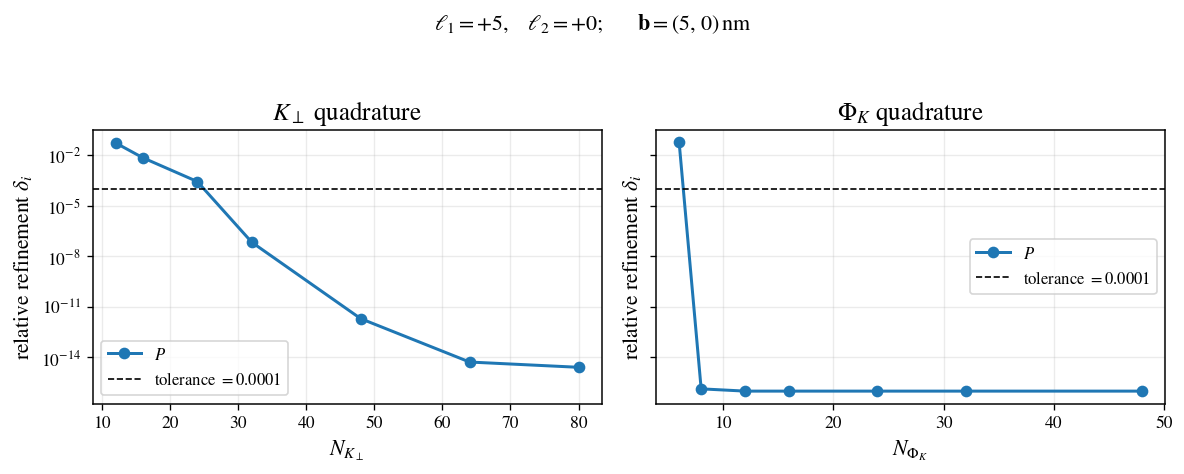

In [14]:
started = time.perf_counter()
total_fixed_value = evaluate_total_probability()
print(
    f"Total probability at the largest outer-grid settings = {total_fixed_value:.12e} "
    f"({time.perf_counter() - started:.2f} s)"
)

total_outer_radial_counts = np.array((8, 12, 16, 24, 32, 48, 64, 80))
total_outer_phi_counts = np.array((4, 6, 8, 12, 16, 24, 32, 48))

total_outer_radial_values = timed_scan(
    r"Total probability: $K_\perp$ nodes",
    total_outer_radial_counts,
    lambda count: evaluate_total_probability(n_outer_radial=count),
)
total_outer_phi_values = timed_scan(
    r"Total probability: $\Phi_K$ nodes",
    total_outer_phi_counts,
    lambda count: evaluate_total_probability(n_outer_phi=count),
)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), sharey=True)
plot_diagnostics(
    axes[0], total_outer_radial_counts[1:],
    relative_step_change(total_outer_radial_values)[1:],
    (r"$P$",), r"$N_{K_\perp}$", r"relative refinement $\delta_i$",
)
plot_diagnostics(
    axes[1], total_outer_phi_counts[1:],
    relative_step_change(total_outer_phi_values)[1:],
    (r"$P$",), r"$N_{\Phi_K}$", r"relative refinement $\delta_i$",
)
axes[0].set_title(r"$K_\perp$ quadrature")
axes[1].set_title(r"$\Phi_K$ quadrature")
fig.suptitle(parameter_text)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
plt.show()


## Numerical summary and acceptance checklist

The last-step change is a compact diagnostic, but it must be read together with the full curves: accidental crossings can make one step look better than the surrounding trend. The automatic choice below is conservative: it selects the first parameter after which **all later measured refinements** remain below `SATURATION_TOLERANCE`.

In [15]:
print("Largest relative change in the last measured refinement:")
print(f"  normalization, radial nodes       : {last_step_change(normalization_kperp_node_values):.3e}")
print(f"  normalization, longitudinal nodes : {last_step_change(normalization_kz_node_values):.3e}")
print(f"  normalization, radial domain      : {last_step_change(normalization_kperp_domain_values):.3e}")
print(f"  normalization, longitudinal domain: {last_step_change(normalization_kz_domain_values):.3e}")
print(f"  differential, radial nodes        : {last_step_change(differential_radial_values):.3e}")
print(f"  differential, angular nodes       : {last_step_change(differential_phi_values):.3e}")
print(f"  total P, K_perp nodes              : {last_step_change(total_outer_radial_values):.3e}")
print(f"  total P, Phi_K nodes               : {last_step_change(total_outer_phi_values):.3e}")
print(f"  differential, last upper shell    : {np.max(differential_upper_fractions[-1]):.3e}")

print(f"\nFirst settings with all later changes below {SATURATION_TOLERANCE:g}:")
recommendations = (
    ("normalization N_kperp", saturation_parameter(
        normalization_node_counts, relative_step_change(normalization_kperp_node_values))),
    ("normalization N_kz", saturation_parameter(
        normalization_node_counts, relative_step_change(normalization_kz_node_values))),
    ("normalization radial widths", saturation_parameter(
        normalization_domain_widths, relative_step_change(normalization_kperp_domain_values))),
    ("normalization longitudinal widths", saturation_parameter(
        normalization_domain_widths, relative_step_change(normalization_kz_domain_values))),
    ("differential N_k3perp", saturation_parameter(
        differential_radial_counts, relative_step_change(differential_radial_values))),
    ("differential N_phi3", saturation_parameter(
        differential_phi_counts, relative_step_change(differential_phi_values))),
    ("differential k3perp,max [MeV]", saturation_parameter(
        differential_upper_limits, differential_upper_fractions)),
    ("total N_Kperp", saturation_parameter(
        total_outer_radial_counts, relative_step_change(total_outer_radial_values))),
    ("total N_PhiK", saturation_parameter(
        total_outer_phi_counts, relative_step_change(total_outer_phi_values))),
)
for name, value in recommendations:
    choice = "not reached in this scan" if value is None else f"{value:g}"
    print(f"  {name:<48} {choice}")

print("\nThe lower k3 cutoff is physical and is therefore not selected automatically.")


Largest relative change in the last measured refinement:
  normalization, radial nodes       : 5.223e-14
  normalization, longitudinal nodes : 4.699e-12
  normalization, radial domain      : 2.252e-13
  normalization, longitudinal domain: 1.723e-12
  differential, radial nodes        : 3.405e-14
  differential, angular nodes       : 1.268e-16
  total P, K_perp nodes              : 2.592e-15
  total P, Phi_K nodes               : 0.000e+00
  differential, last upper shell    : 7.774e-05

First settings with all later changes below 0.0001:
  normalization N_kperp                            32
  normalization N_kz                               64
  normalization radial widths                      8
  normalization longitudinal widths                5
  differential N_k3perp                            12
  differential N_phi3                              6
  differential k3perp,max [MeV]                    1
  total N_Kperp                                    32
  total N_PhiK              

Before accepting any probability map or derived graph:

1. Require several consecutive relative refinements below the selected tolerance for both normalization axes and both normalization domains.
2. State the physical $k_{3\perp}$ window explicitly; never hide the lower cutoff in generic numerical settings.
3. Check the inner radial and angular convergence at the center, a characteristic point, and the tail of the intended $K_\perp$ map. Add probes near any sharp feature.
4. For integrated observables, require saturation of both outer axes, $K_\perp$ and $\Phi_K$.
5. Choose a tolerance appropriate to the claim in the plot. For a percent-level conclusion, the observed numerical changes should be comfortably below one percent, preferably by at least an order of magnitude.
6. Recompute the final observable with all selected node counts increased together. The resulting relative change guards against coupled errors that one-axis scans can miss.
7. Remember the dimensions: $dP/d^2K_\perp$ is reported in MeV$^{-2}$, $K_x$ and $K_y$ are displayed in eV, and $P$ is dimensionless.
